In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
from scipy import special
from typing import Any, Literal
from pathlib import Path

In [2]:
from info_patterns.parameters import (ELLIPSOID_GEOMETRY_PARAMS, DEFAULT_MATERIAL_NAME, DEFAULT_MATERIAL_KWARGS, DEFAULT_WAVELENGTH_NM, FAST_FARFIELD_PARAMS, DEFAULT_DYADS_PARAMS, DEFAULT_COM_DISPLACEMENT_NM, 
                            DEFAULT_LIBRATION_ANGLE_DEG, DEFAULT_USETEX, DEFAULT_FONT_FAMILY, DEFAULT_FIGSIZE, DEFAULT_SAVE_TYPE, DEFAULT_2D_PLANES, DEFAULT_2D_NORMALIZE, DEFAULT_2D_FILL)
from info_patterns.constants import (C, EPS0, NM_TO_M)
from info_patterns.generate_nanoparticle import (nanoparticle_geometry, nanoparticle_material)
from info_patterns.light_matter_interaction_simulation import (incident_field, field_propagation, librational_scattered_farfield)
from info_patterns.information_patterns_simulation import (info_patterns_from_scattered_field)
from info_patterns.plots import (set_plot_style, plot3d_info_patterns, plot2d_info_patterns)

set_plot_style(usetex=DEFAULT_USETEX, font_family=DEFAULT_FONT_FAMILY, figsize=DEFAULT_FIGSIZE)
results_dir = "lib_ellipse_results"

In [3]:
geometry = nanoparticle_geometry(**ELLIPSOID_GEOMETRY_PARAMS)
material = nanoparticle_material(DEFAULT_MATERIAL_NAME, **DEFAULT_MATERIAL_KWARGS)
step_nm = ELLIPSOID_GEOMETRY_PARAMS["step_nm"]

In [4]:
def parabolic_mirror_efield(pos: np.ndarray, env_dict: dict[str, Any], wavelength: float, n_medium: float, f: float, alpha_0: float, alpha_1: float, w_0: float, N: float, 
                            theta_size: int, xSpot: float, ySpot: float, zSpot: float, returnField: Literal["E", "B", "H"] = "E") -> np.ndarray:
    """
    Parabolic-mirror incident electric field for pyGDM2
    (Lieb & Meixner, Opt. Express 2001), based on Eqs. (2)–(3)
    for a linearly x-polarized focused field.

    This function is meant to be used as a `field_generator` inside
    `pyGDM2.fields.efield`. pyGDM2 supplies `pos`, `env_dict`, and
    `wavelength` automatically. The remaining parameters are passed
    through `kwargs`.

    Parameters
    ----------
    pos : np.ndarray
        Dipole positions in nm with shape approximately (Npoints, 3).

    env_dict : dict[str, Any]
        Environment dictionary provided by pyGDM2.
        Not used here, kept for API compatibility.

    wavelength : float
        Wavelength in nm.

    n_medium : float
        Refractive index of the medium around the focus.

    f : float
        Parabolic mirror focal length in nm.

    alpha_0 : float
        Minimum acceptance angle in radians. Use > 0 to model
        a central obscuration.

    alpha_1 : float
        Maximum acceptance/opening angle of the mirror in radians.

    w_0 : float
        Waist radius of the illuminating Gaussian beam on the mirror
        pupil in nm.

    N : float
        Overall amplitude/normalization factor of the incident beam
        profile l0(theta).

    theta_size : int
        Number of samples for the theta integration.

    xSpot, ySpot, zSpot : float
        Focus position in nm. The field is evaluated at pos - spot.

    returnField : Literal["E", "B", "H"]
        Requested field type from pyGDM2. Only "E" is provided.

    Returns
    -------
    E : np.ndarray
        Incident electric field components [Ex, Ey, Ez] evaluated at
        each dipole position. Returned as complex64 and Fortran-ordered.
    """
    # We do not provide B/H field
    if returnField !="E":
        return np.asfortranarray(np.zeros((len(pos), 3), dtype=np.complex64))
    
    # Initial position of the particle
    pos = np.asarray(pos, dtype=float)
    x_p = pos[:, 0] - xSpot
    y_p = pos[:, 1] - ySpot
    z_p = pos[:, 2] - zSpot

    k = 2 * np.pi * n_medium / wavelength # [1/nm] wavelength is in nm in pyGDM2

    # Integration variable theta = theta_m
    theta = np.linspace(alpha_0, alpha_1, theta_size) # [rad]
    r = 2 * f * np.tan(theta / 2) # [nm]
    
    l0_theta = N * np.exp(-(r**2) / (w_0**2))
    apod = (2 * np.sin(theta) / (1 + np.cos(theta))) # Mirror apodization factor: 2 sinθ / (1+cosθ)

    # Spherical coords of observation points P (each dipole position)
    r_p = np.sqrt(x_p**2 + y_p**2 + z_p**2) # [nm]
    phi_p = np.arctan2(y_p, x_p)

    # handle r_p = 0 safely
    safe = np.where(r_p > 0, r_p, 1.0)
    cos_theta_p = z_p / safe
    cos_theta_p = np.clip(cos_theta_p, -1.0, 1.0)
    theta_p = np.arccos(cos_theta_p)
    sin_theta_p = np.sin(theta_p)

    # Broadcast over (theta_size, Npoints)
    ct = np.cos(theta)[:, None]
    st = np.sin(theta)[:, None]

    phase = np.exp(-1j * k * (r_p[None, :]) * ct * (cos_theta_p[None, :]))
    argument = k * (r_p[None, :]) * st * (sin_theta_p[None, :])

    # Integrands (Eq. 3), with J0/J1/J2
    integrand_I0 = (l0_theta[:, None] * apod[:, None] * (1 + np.cos(theta))[:, None] * special.jv(0, argument) * phase)
    integrand_I1 = (l0_theta[:, None] * apod[:, None] * (np.sin(theta))[:, None] * special.jv(1, argument) * phase)
    integrand_I2 = (l0_theta[:, None] * apod[:, None] * (1 - np.cos(theta))[:, None] * special.jv(2, argument) * phase)

    I_0l = np.trapz(integrand_I0, theta, axis=0)
    I_1l = np.trapz(integrand_I1, theta, axis=0)
    I_2l = np.trapz(integrand_I2, theta, axis=0)

    # Electric field components
    Ex = ((1j * k * f) / 2) * (I_0l + I_2l * np.cos(2 * phi_p))
    Ey = ((1j * k * f) / 2) * (I_2l * np.sin(2 * phi_p))
    Ez = -k * f * I_1l * np.cos(phi_p)

    return np.asfortranarray(np.transpose([Ex, Ey, Ez])).astype(np.complex64)

In [5]:
wavelength_nm = DEFAULT_WAVELENGTH_NM

# Medium and parabolic mirror parameters
n_medium = 1.0
f = 1.0e6  # nm
power_W = 1e-3

num_app_NA = 0.994475
theta_size = 300

xSpot = 0.0
ySpot = 0.0
zSpot = 0.0

alpha_0 = 0.0
alpha_1 = np.arcsin(num_app_NA / n_medium)

r0_nm = 2.0 * f * np.tan(alpha_0 / 2.0)
r1_nm = 2.0 * f * np.tan(alpha_1 / 2.0)

w0_nm = 1.5 * r1_nm

r0_m = r0_nm * NM_TO_M
r1_m = r1_nm * NM_TO_M
w0_m = w0_nm * NM_TO_M

delta_exps = (np.exp(-2.0 * r0_m**2 / w0_m**2) - np.exp(-2.0 * r1_m**2 / w0_m**2))
N_physical = np.sqrt(4.0 * power_W / (n_medium * EPS0 * C * np.pi * w0_m**2 * delta_exps))
parabolic_mirror_field_params = {"field_generator": parabolic_mirror_efield, "wavelengths": [wavelength_nm], "n_medium": n_medium, "f": f, "alpha_0": alpha_0, "alpha_1": alpha_1, "w_0": w0_nm, 
                                 "N": N_physical, "theta_size": theta_size, "xSpot": xSpot, "ySpot": ySpot, "zSpot": zSpot}
farfield_params = FAST_FARFIELD_PARAMS

Nteta = farfield_params["Nteta"]
Nphi = farfield_params["Nphi"]
field_index = farfield_params["field_index"]
r = farfield_params["r"]

disp_nm = DEFAULT_COM_DISPLACEMENT_NM
angle_deg = DEFAULT_LIBRATION_ANGLE_DEG

efield = incident_field(**parabolic_mirror_field_params)
dyads = field_propagation(**DEFAULT_DYADS_PARAMS)

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 1762.9ms, inv.: 957.4ms, repropa.: 144.8ms (1 field configs), tot: 2865.3ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 83.4ms, inv.: 831.7ms, repropa.: 135.1ms (1 field configs), tot: 1050.3ms


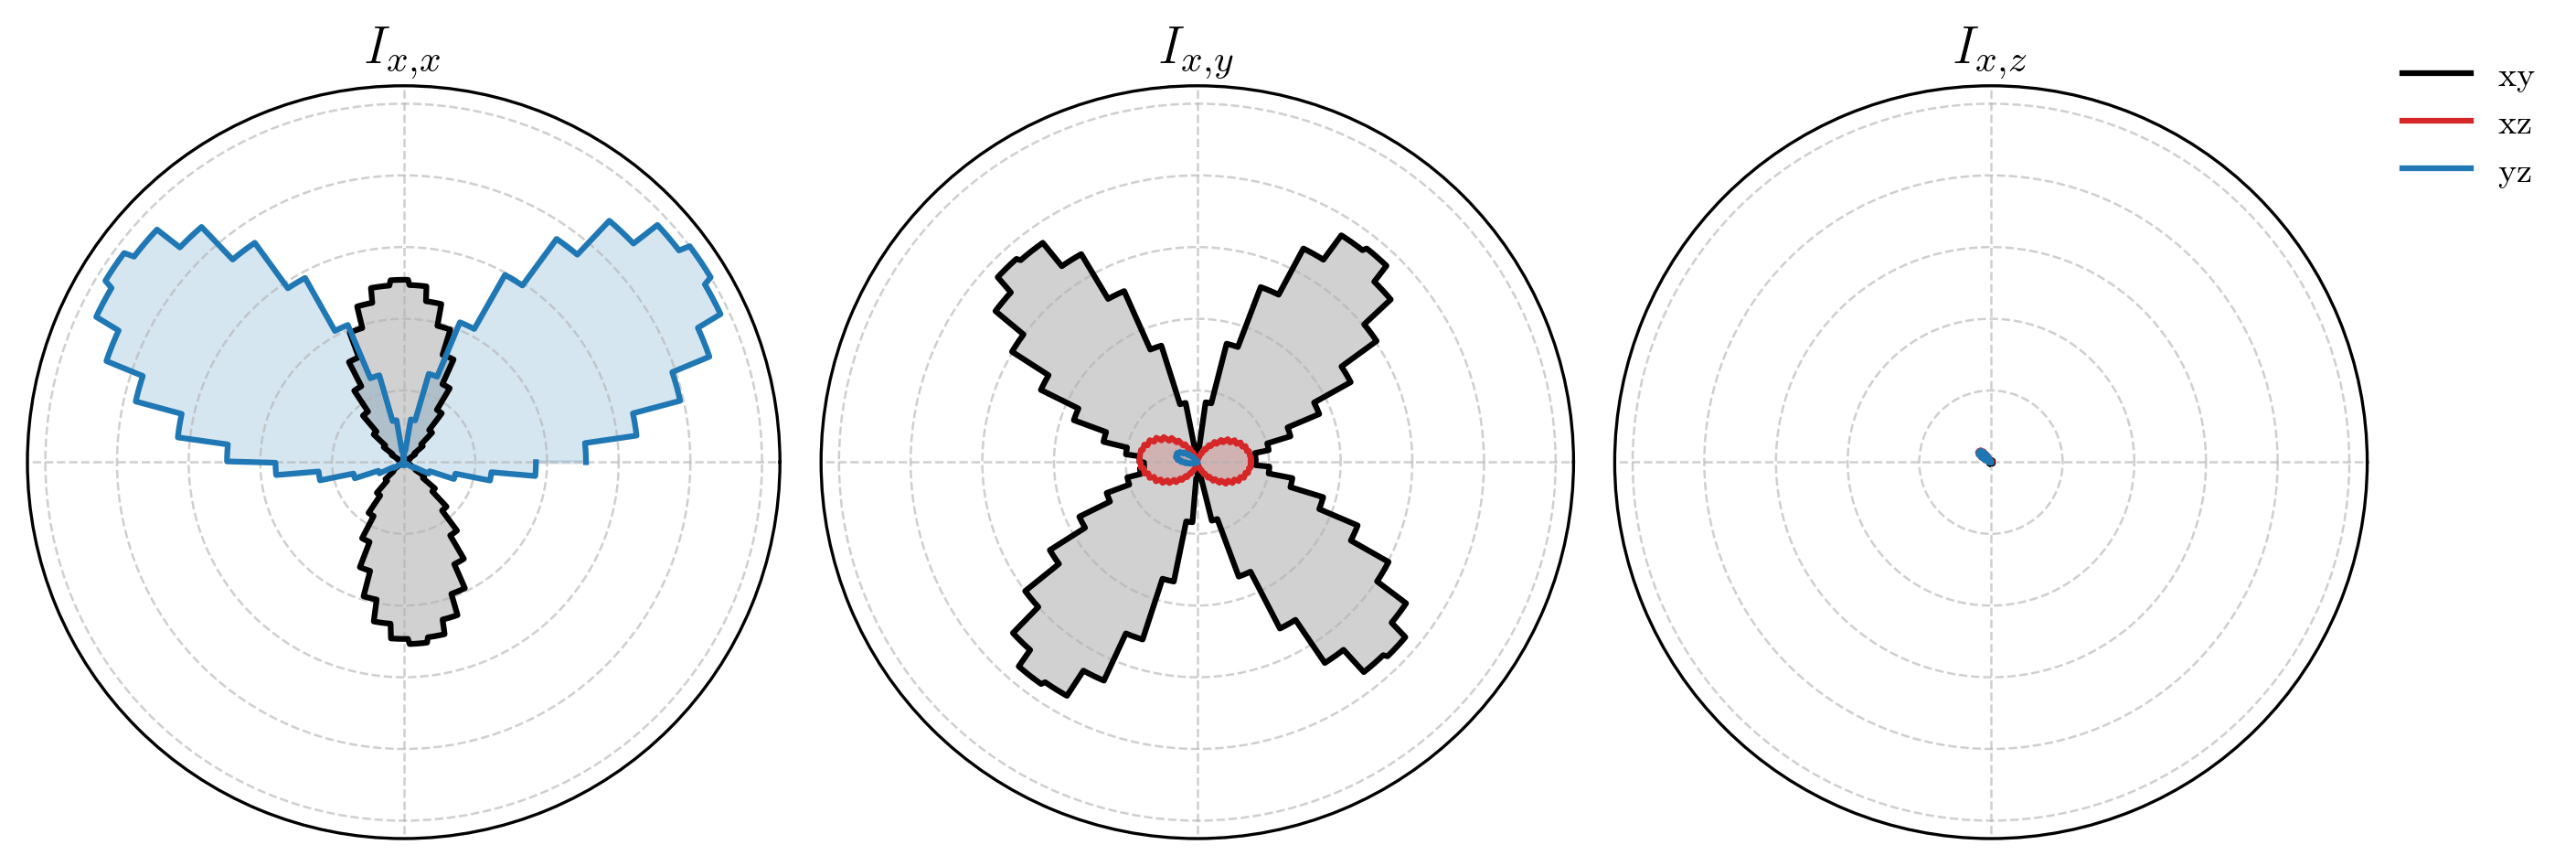

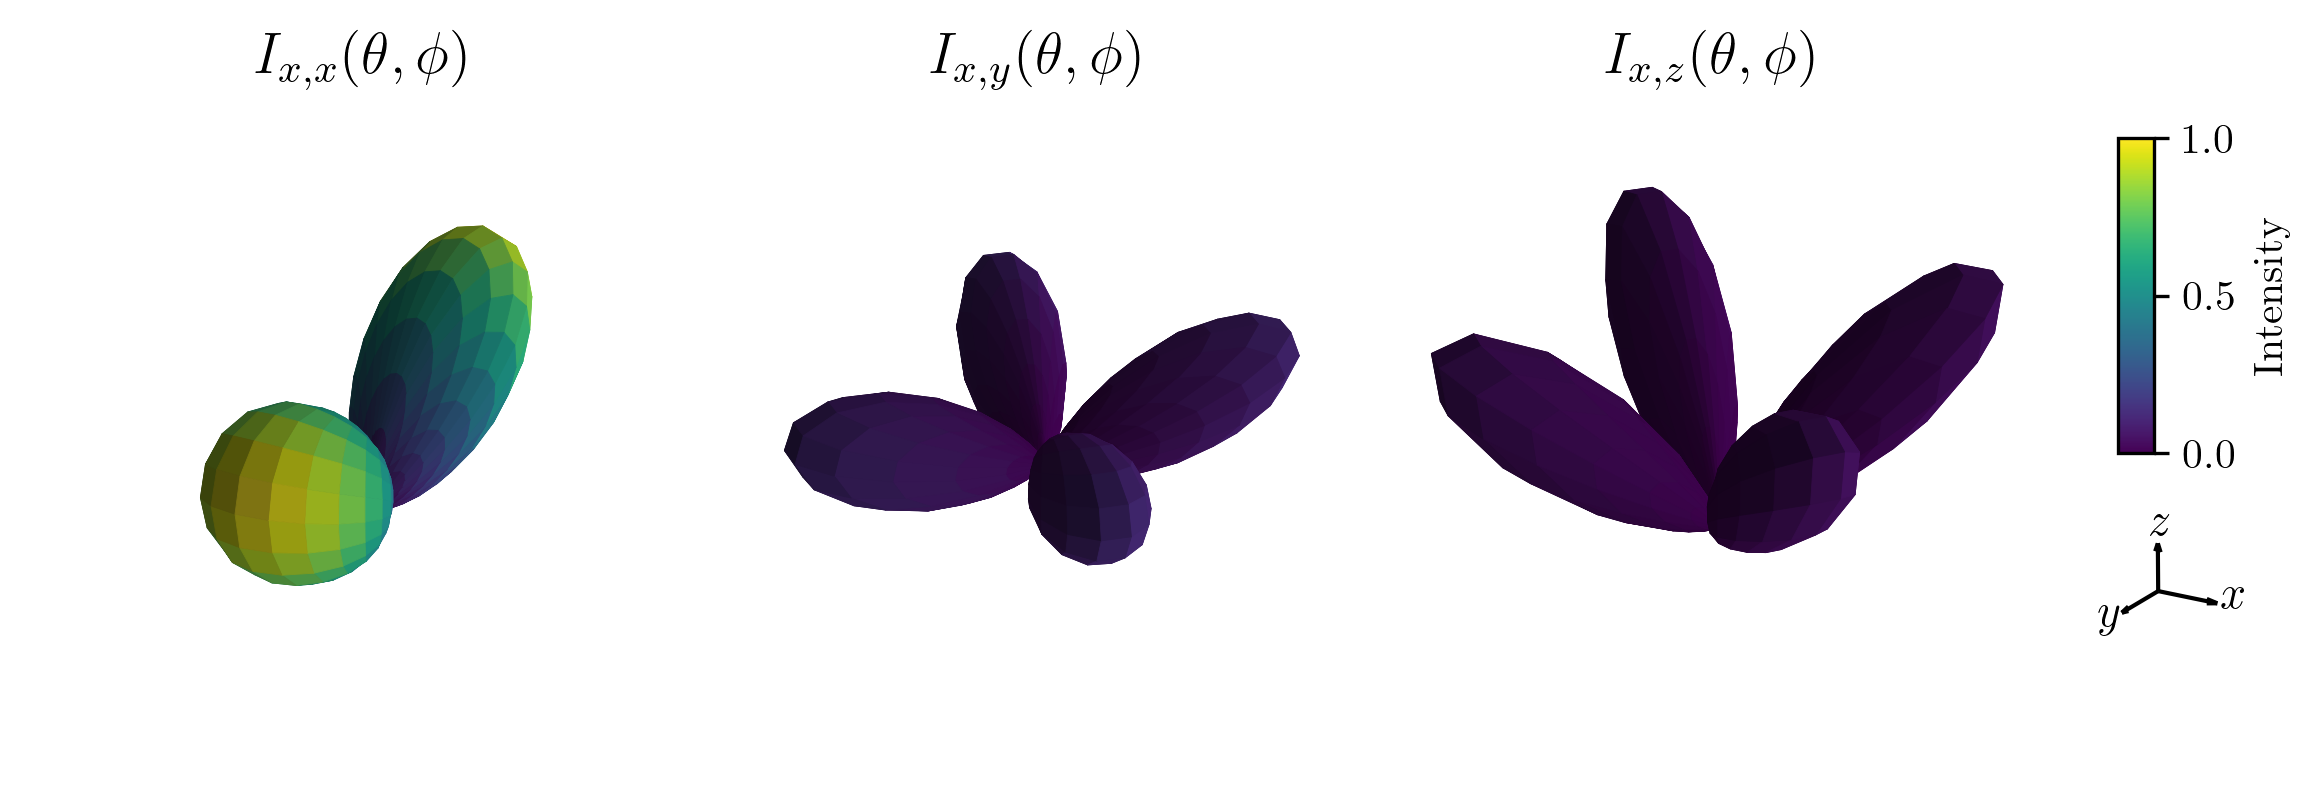

In [6]:
E_lib_plus_x, E_lib_minus_x, dE_lib_x = librational_scattered_farfield(geometry=geometry, step_nm=step_nm, material=material, efield=efield, dyads=dyads, axis_index=0, angle_deg=angle_deg, 
                                                                       Nteta=Nteta, Nphi=Nphi, field_index=field_index, r=r)
I_lib_x_total, I_lib_x_Ex, I_lib_x_Ey, I_lib_x_Ez = info_patterns_from_scattered_field(dE=dE_lib_x, delta_mu=angle_deg, wavelength_nm=wavelength_nm, Nteta=Nteta, Nphi=Nphi)
plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_lib_x_Ex, I_lib_x_Ey, I_lib_x_Ez], labels=["x,x", "x,y", "x,z"], planes=DEFAULT_2D_PLANES, 
                     normalize=DEFAULT_2D_NORMALIZE, fill=DEFAULT_2D_FILL, figsize=None, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="lib_info_patterns_x_2d", 
                     results_dir=results_dir)
plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_lib_x_Ex, I_lib_x_Ey, I_lib_x_Ez], labels=["x,x", "x,y", "x,z"], cmap=cm.viridis, 
                     scale_list=[0.3, 0.38, 0.38], savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="lib_info_patterns_x_3d", results_dir=results_dir)

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 101.2ms, inv.: 807.2ms, repropa.: 138.4ms (1 field configs), tot: 1046.9ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 89.6ms, inv.: 903.9ms, repropa.: 168.0ms (1 field configs), tot: 1161.6ms


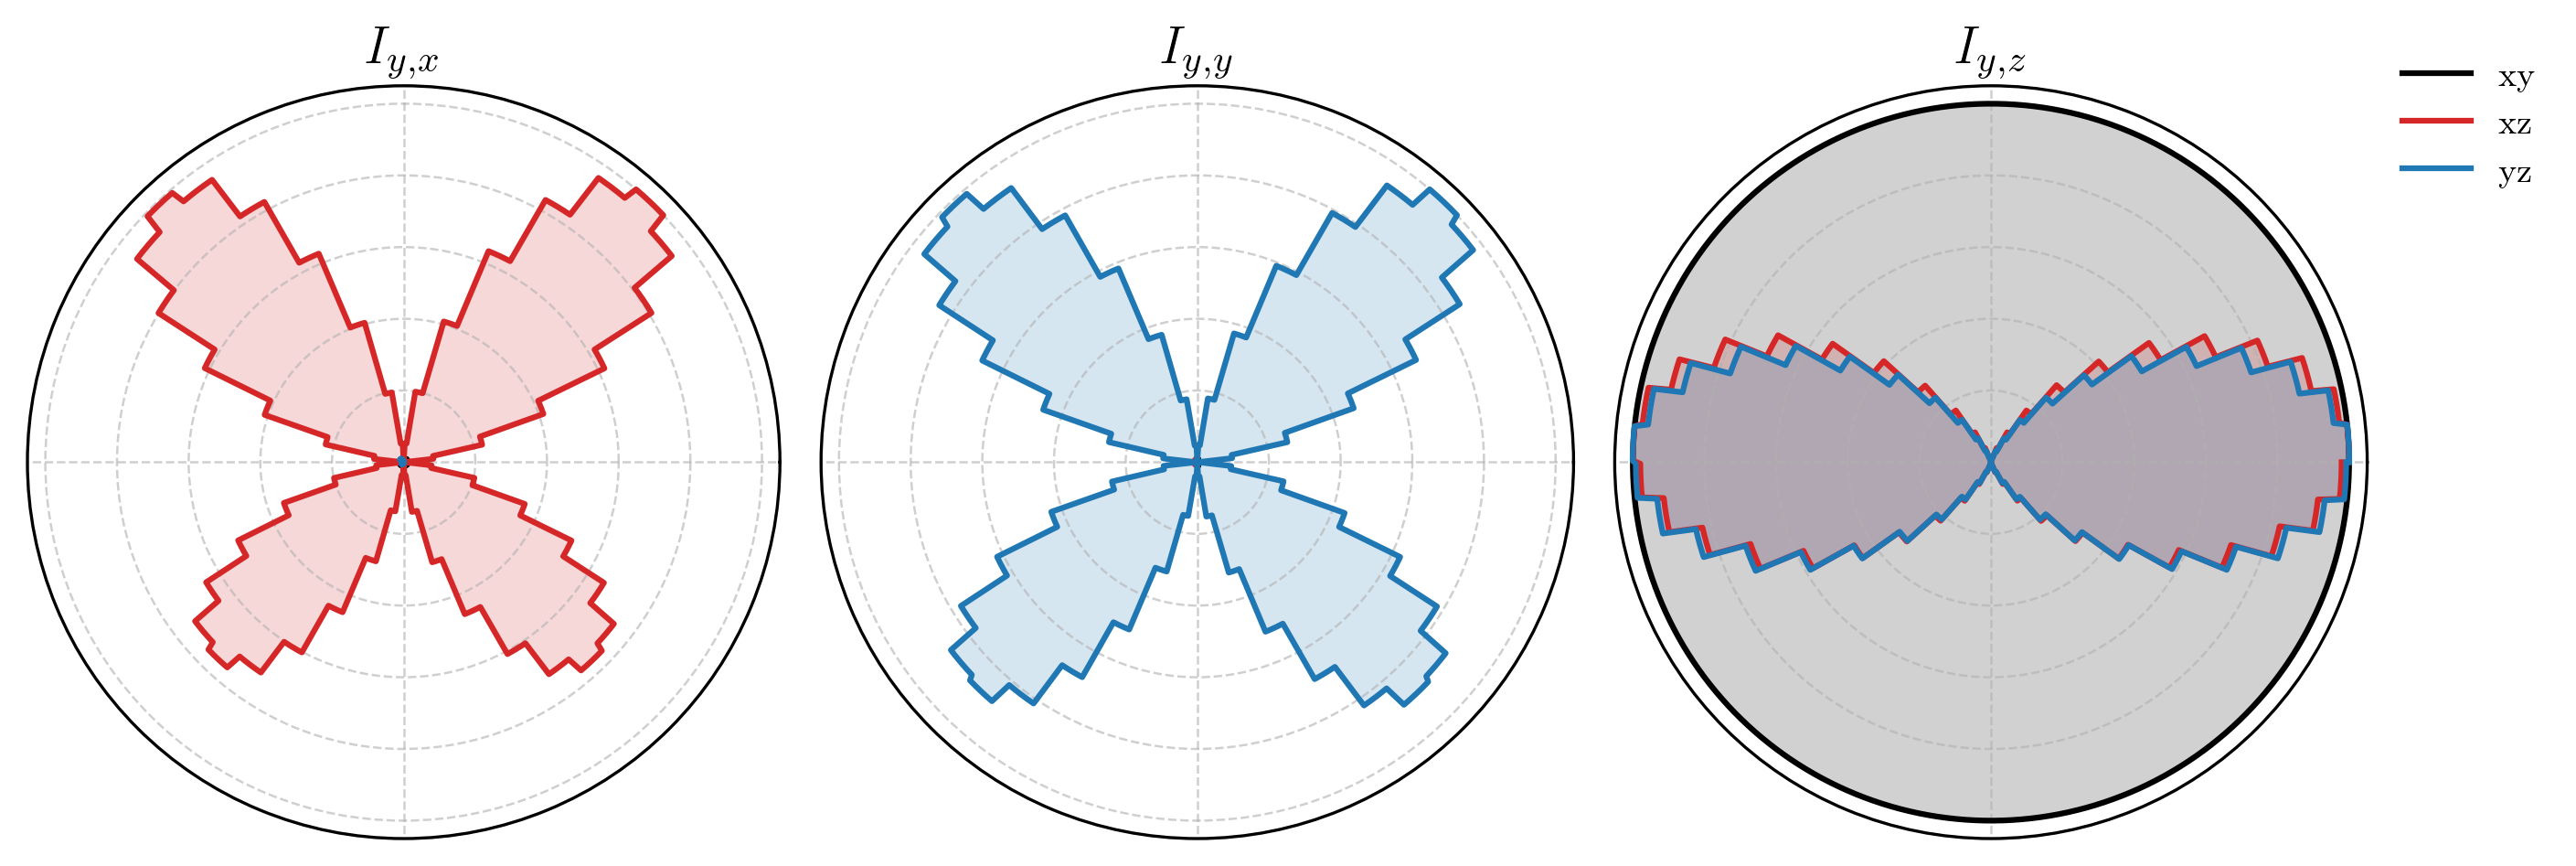

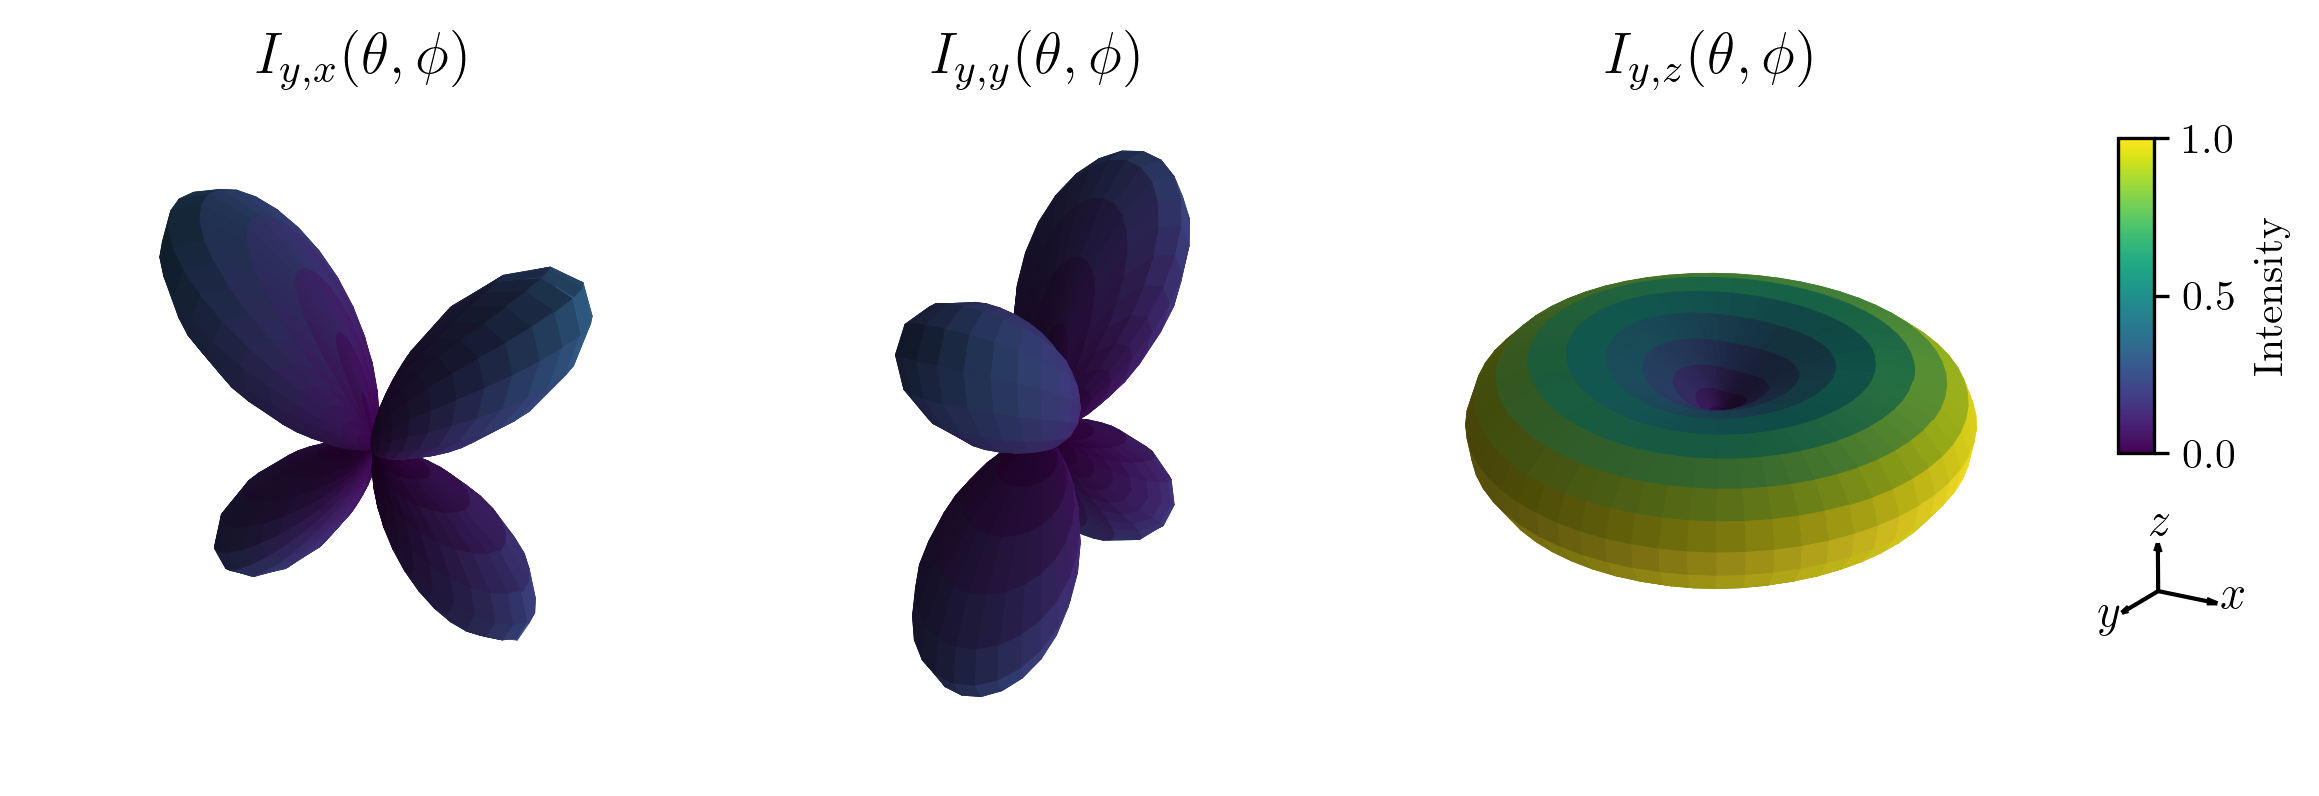

In [7]:
E_lib_plus_y, E_lib_minus_y, dE_lib_y = librational_scattered_farfield(geometry=geometry, step_nm=step_nm, material=material, efield=efield, dyads=dyads, axis_index=1, angle_deg=angle_deg, 
                                                                       Nteta=Nteta, Nphi=Nphi, field_index=field_index, r=r)
I_lib_y_total, I_lib_y_Ex, I_lib_y_Ey, I_lib_y_Ez = info_patterns_from_scattered_field(dE=dE_lib_y, delta_mu=angle_deg, wavelength_nm=wavelength_nm, Nteta=Nteta, Nphi=Nphi)
plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_lib_y_Ex, I_lib_y_Ey, I_lib_y_Ez], labels=["y,x", "y,y", "y,z"], planes=DEFAULT_2D_PLANES, 
                     normalize=DEFAULT_2D_NORMALIZE, fill=DEFAULT_2D_FILL, figsize=None, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="lib_info_patterns_y_2d", 
                     results_dir=results_dir)
plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_lib_y_Ex, I_lib_y_Ey, I_lib_y_Ez], labels=["y,x", "y,y", "y,z"], cmap=cm.viridis, scale_list=[0.38, 0.38, 0.34], savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="lib_info_patterns_y_3d", results_dir=results_dir)

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 137.2ms, inv.: 873.8ms, repropa.: 152.8ms (1 field configs), tot: 1164.0ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 85.4ms, inv.: 876.2ms, repropa.: 137.2ms (1 field configs), tot: 1099.1ms


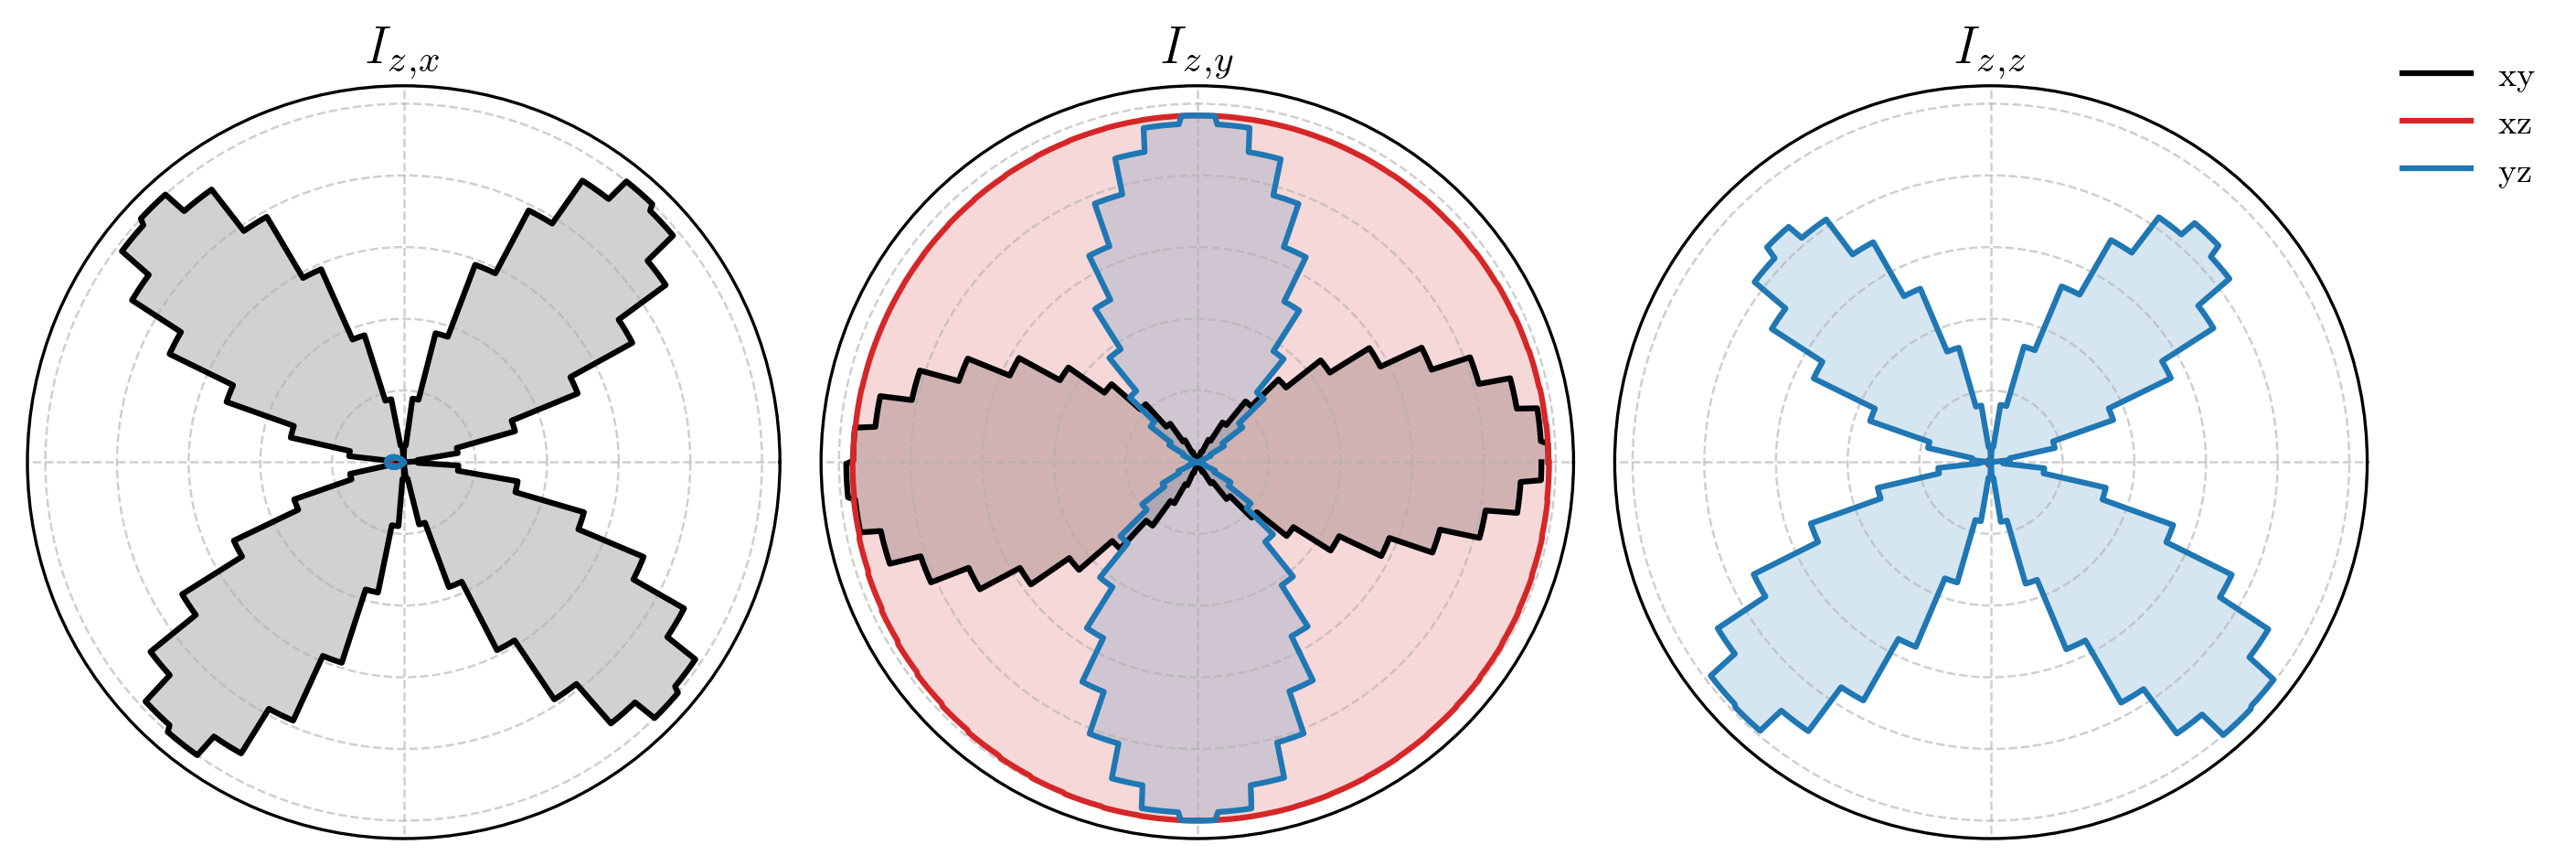

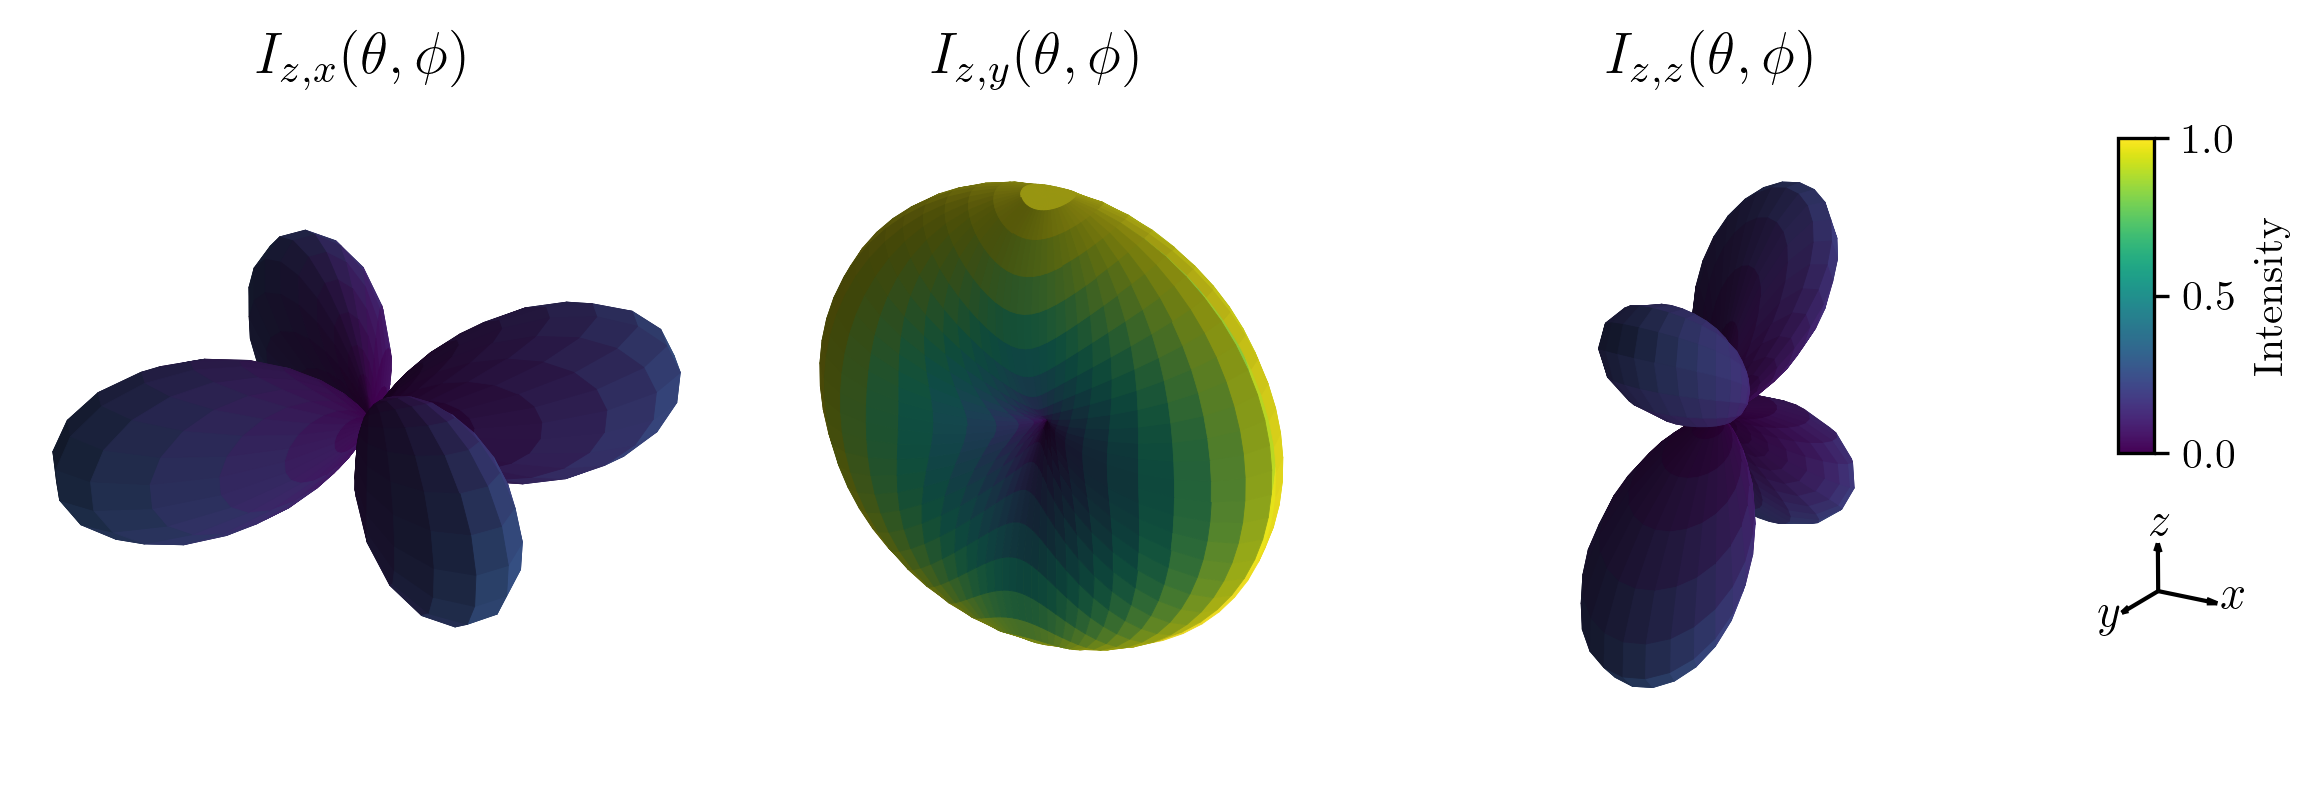

In [8]:
E_lib_plus_z, E_lib_minus_z, dE_lib_z = librational_scattered_farfield(geometry=geometry, step_nm=step_nm, material=material, efield=efield, dyads=dyads, axis_index=2, angle_deg=angle_deg, 
                                                                       Nteta=Nteta, Nphi=Nphi, field_index=field_index, r=r)
I_lib_z_total, I_lib_z_Ex, I_lib_z_Ey, I_lib_z_Ez = info_patterns_from_scattered_field(dE=dE_lib_z, delta_mu=angle_deg, wavelength_nm=wavelength_nm, Nteta=Nteta, Nphi=Nphi)
plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_lib_z_Ex, I_lib_z_Ey, I_lib_z_Ez], labels=["z,x", "z,y", "z,z"], planes=DEFAULT_2D_PLANES, normalize=DEFAULT_2D_NORMALIZE, 
                     fill=DEFAULT_2D_FILL, figsize=None, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="lib_info_patterns_z_2d", results_dir=results_dir)
plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_lib_z_Ex, I_lib_z_Ey, I_lib_z_Ez], labels=["z,x", "z,y", "z,z"], cmap=cm.viridis, scale_list=[0.34, 0.34, 0.4], savefig=False, 
                     save_type=DEFAULT_SAVE_TYPE, filename="lib_info_patterns_z_3d", results_dir=results_dir)

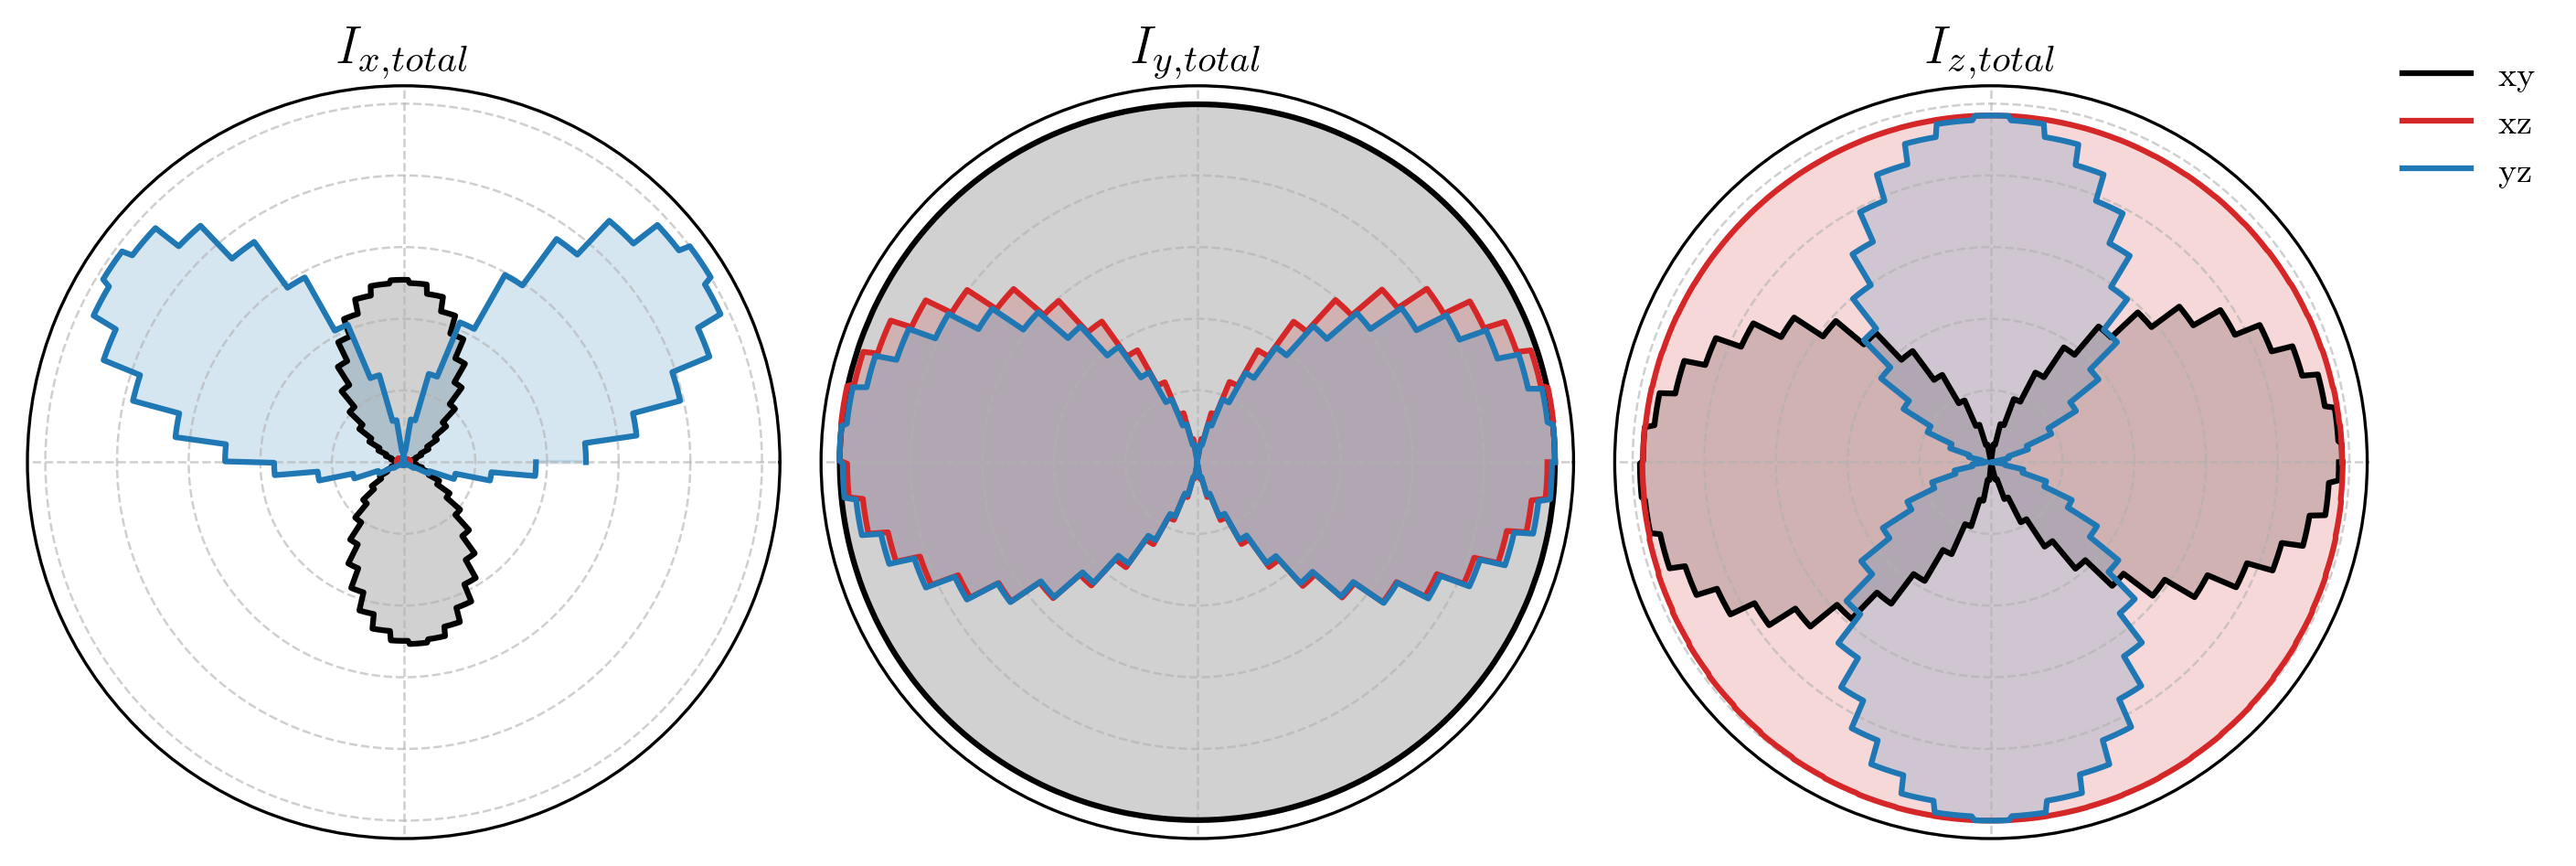

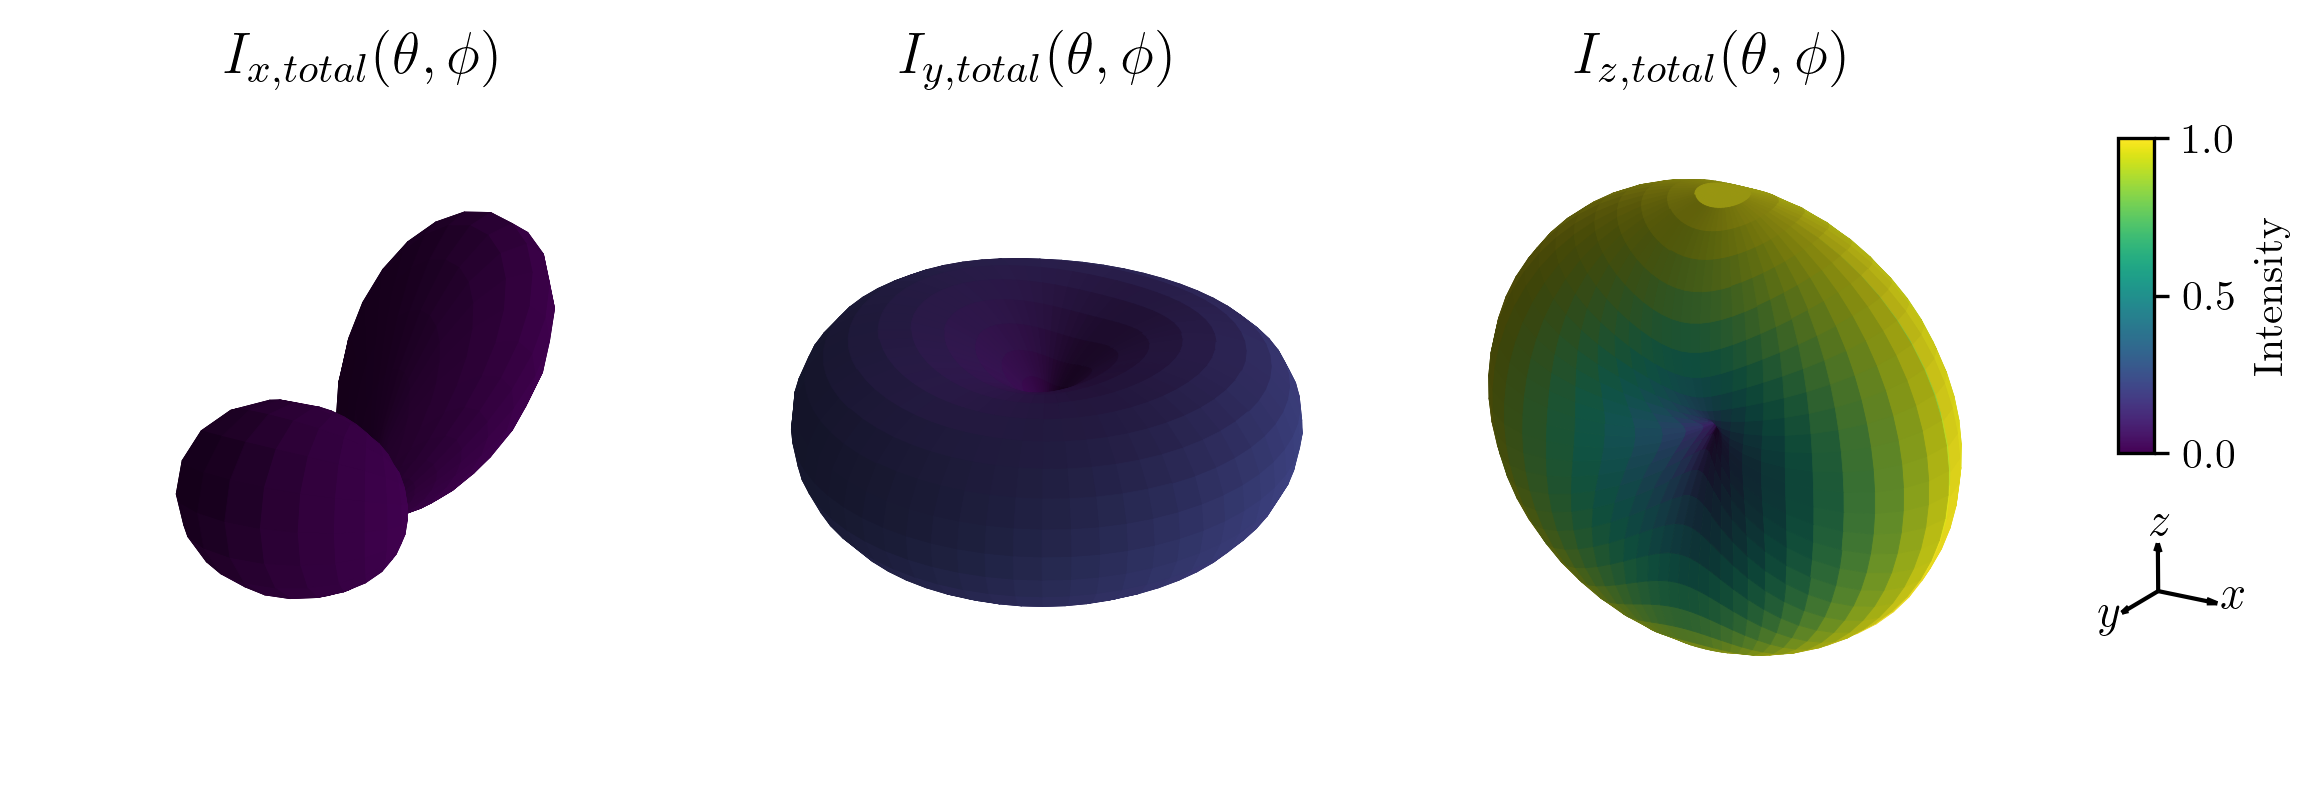

In [9]:
plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_lib_x_total, I_lib_y_total, I_lib_z_total], labels=["x,total", "y,total", "z,total"], planes=DEFAULT_2D_PLANES, 
                     normalize=DEFAULT_2D_NORMALIZE, fill=DEFAULT_2D_FILL, figsize=None, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="lib_info_patterns_total_2d", results_dir=results_dir)
plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_lib_x_total, I_lib_y_total, I_lib_z_total], labels=["x,total", "y,total", "z,total"], cmap=cm.viridis, scale_list=[0.28, 0.34, 0.34], 
                     savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="lib_info_patterns_total_3d", results_dir=results_dir)